<center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="300" alt="cognitiveclass.ai logo">
</center>

# Understanding  Generative Adversarial Networks GANs

Estimated time needed: **35** minutes

In this lab, we will focus on simulated data to better understand Generative Adversarial Networks (GANs).


## **Table of Contents**

<ol>
    <li><a href="https://#Objectives">Objectives</a></li>
    <li>
        <a href="https://#Setup">Setup</a>
    </li>
    <li>
        <a href="https://#Background">Background</a>
    </li>
    <li>
        <a href="https://#Toy Data">Toy Data</a>
    </li>
    <li>
        <a href="https://#The Generator">The Generator</a>
    </li>
    <li>
        <a href="https://#The Discriminator">The Discriminator</a>
    </li>
        <li>
        <a href="https://#The Loss Function GANs (Optional)">The Loss Function GANs (Optional)</a>
            <ol>
            <li><a href="https://#Discriminator">Discriminator</a></li>
            <li><a href="https://#Generator">Generator</a></li>
        </ol>
        </li>
    <li>
        <a href="https://#Training GANs">Training GANs</a>
         <ol>
            <li><a href="https://#Training Generator">Training Generator</a></li>
             <li><a href="https://#Training Discriminator">Training Discriminator</a></li>
        </ol>
    </li>


## Objectives

After completing this lab, you will be able to:

*   **Understand** the original formulation of GANs, and their two separately trained networks: Generator and Discriminator
*   **Implement** GANs on simulated and real datasets


For this lab, we will be using the following libraries:

*   [`pandas`](https://pandas.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for managing the data.
*   [`numpy`](https://numpy.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for mathematical operations.
*   [`sklearn`](https://scikit-learn.org/stable/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for machine learning and machine-learning-pipeline related functions.
*   [`seaborn`](https://seaborn.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for visualizing the data.
*   [`matplotlib`](https://matplotlib.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for additional plotting tools.
*   [`keras`](https://keras.io/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for loading datasets.


### Installing Required Libraries

The following required libraries are pre-installed in the Skills Network Labs environment. However, if you run these notebook commands in a different Jupyter environment (like Watson Studio or Ananconda), you will need to install these libraries by removing the `#` sign before `!pip3 install --upgrade tensorflow` in the cell below.


In [1]:
# All Libraries required for this lab are listed below. The libraries pre-installed on Skills Network Labs are commented.
# !mamba install -qy pandas==1.3.4 numpy==1.21.4 seaborn==0.9.0 matplotlib==3.5.0 scikit-learn==0.20.1
# Note: If your environment doesn't support "!mamba install", use "!pip install"

In [2]:
#!pip3 install --upgrade tensorflow

### Importing Required Libraries


In [3]:
import warnings
warnings.simplefilter('ignore')

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' 

import numpy as np
import os
import matplotlib.pyplot as plt
import tensorflow as tf
print(tf.__version__)
from tensorflow.keras import layers
import time
from tensorflow.keras import models
from tqdm import tqdm

1.14.0


### Helper function


In [4]:
def plot_distribution(real_data,generated_data,discriminator=None,density=True):
    
    plt.hist(real_data.numpy(), 100, density=density, facecolor='g', alpha=0.75, label='real data')
    plt.hist(generated_data.numpy(), 100, density=density, facecolor='r', alpha=0.75,label='generated data q(z) ')
    
    if discriminator:
        max_=np.max([int(real_data.numpy().max()),int(generated_data.numpy().max())])
        min_=np.min([int(real_data.numpy().min()),int(generated_data.numpy().min())])
        x=np.linspace(min_, max_, 1000).reshape(-1,1)
        plt.plot(x,tf.math.sigmoid(discriminator(x,training=False).numpy()),label='discriminator',color='k')
        plt.plot(x,0.5*np.ones(x.shape),label='0.5',color='b')
        plt.xlabel('x')
        
    plt.legend()
    plt.show()

## Background


Generative Adversarial Networks (GANs) are generative models that convert random samples of one distribution into another distribution. They have several applications, like the following:

*   Generate Examples for Image Datasets
*   Generate Photographs of Human Faces
*   Generate Realistic Photographs
*   Generate Cartoon Characters
*   Image-to-Image Translation
*   Text-to-Image Translation
*   Face Frontal View Generation
*   Generate New Human Poses
*   Face Aging
*   Photo Blending
*   Super Resolution
*   Photo Inpainting
*   Clothing Translation
*   Video Prediction

In this lab, we will use a toy example to help understand the basic theoretical principles behind GANs. The original form of GANs consisted of a discriminator and a generator; let's use the analogy of a currency forger and the police.

The Generator is the currency forger, and the output is the counterfeit, for example, a 100-dollar bill. The discriminator is analogous to the police taking the counterfeit and trying to determine if it's real by comparing it to a real $100 bill. In real life, if the counterfeit is easy to detect, the forger will adapt; conversely, the police will also improve; GANs emulate this game of cat and mouse.

What makes GANs interesting is that the discriminator and generator continuously improve each other by a well-formulated cost function that backpropagates the errors. GANs are a family of algorithms that use *learning by comparison*. In the lab, we will review the original formulation and use a simulated dataset. We will also point you to some more advanced methods and issues you will encounter with the real datasets for the next lab.

生成对抗网络（GAN，Generative Adversarial Networks）是一类生成模型，其目标是将一个分布中的随机样本**转换为另一个目标分布中的样本**。它们具有广泛的应用，包括：

* 生成图像数据集中的样本
* 生成真人面部照片
* 生成逼真的图像
* 生成卡通角色
* 图像到图像的转换
* 文本到图像的转换
* 正面人脸生成
* 生成新的人体姿态
* 人脸年龄变化模拟
* 图像混合
* 超分辨率（放大图像）
* 图像修复（Photo Inpainting）
* 服装图像转换
* 视频预测

---

在本实验中，我们将使用一个**玩具示例**来帮助理解 GAN 背后的基本理论原理。最初形式的 GAN 由两个部分组成：**判别器（Discriminator）**和**生成器（Generator）**。我们可以把它类比为“造假者”和“警察”的对抗：

* 生成器相当于伪钞制造者，输出的就是“假钞”（例如伪造的100美元钞票）；
* 判别器就像警察，它的任务是判断这张钞票是真是假，方法是把伪造品和真正的100美元进行比较。

现实中，如果假钞很容易被识破，造假者会提高技术；反过来，警察也会改进识别手段。GAN 就是在模拟这场“猫鼠游戏”。

---

GAN 的有趣之处在于，**生成器和判别器通过一个精心设计的损失函数互相提升**。这个损失函数通过反向传播不断调整它们的参数，使双方在对抗中共同进步。GAN 是一种\*\*基于比较学习（learning by comparison）\*\*的算法。

在本实验中，我们将回顾 GAN 的原始形式并使用一个**模拟数据集**。同时，我们还会引导你了解一些更高级的 GAN 变体和在真实数据集上会遇到的挑战（将在下一次实验中探讨）。



<h2 id="about_dataset">Toy Data</h2>

Consider the following data, $\mathbf{x}$, that is normally distributed $\mathbf{x} \sim \mathcal{N}(\mathbf{x}|10,1) $ with a mean of 10 and a standard deviation of 1. Now we would like to randomly sample data from this distribution.


In [5]:
mean = [10]
cov = [[1]]
X = tf.random.normal((5000,1), mean=10, stddev=1.0)
print("mean:", tf.reduce_mean(X))
print("standard deviation:", tf.math.reduce_std(X))



mean: Tensor("Mean:0", shape=(), dtype=float32)
standard deviation: Tensor("reduce_std/Sqrt:0", shape=(), dtype=float32)


We also have the data sample, z, which is also normally distributed $\mathbf{z} \sim \mathcal{N}(\mathbf{z}|0,2) $, with mean of 0 and a standard deviation of 2:


In [6]:
Z = tf.random.normal((5000,1),mean=0,stddev=2)

In [7]:
print("mean:", tf.reduce_mean(Z))
print("standard deviation:", tf.math.reduce_std(Z))

mean: Tensor("Mean_1:0", shape=(), dtype=float32)
standard deviation: Tensor("reduce_std_1/Sqrt:0", shape=(), dtype=float32)


Let's compare the two distributions:


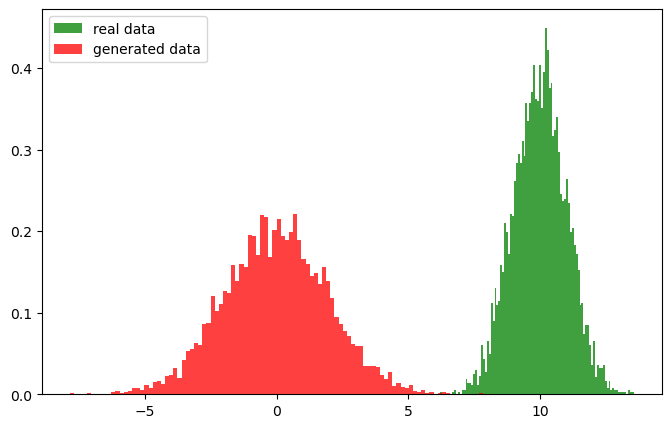

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import backend as K

def plot_distribution(real_data, generated_data, discriminator=None, density=True):
    # 如果是 Tensor，就通过 K.eval() 转成 NumPy 数组
    if tf.is_tensor(real_data):
        real_data = K.eval(real_data)
    if tf.is_tensor(generated_data):
        generated_data = K.eval(generated_data)

    plt.figure(figsize=(8,5))
    plt.hist(real_data.ravel(), bins=100, density=density,
             facecolor='g', alpha=0.75, label='real data')
    plt.hist(generated_data.ravel(), bins=100, density=density,
             facecolor='r', alpha=0.75, label='generated data')
    plt.legend()
    plt.show()

plot_distribution(X,Z)

Let's create our first generative model by adding 10 to every sample of $z$. We will call the result $\hat{\mathbf{x}}$  as it's an approximation of $\mathbf{x}$. It is not too difficult to show that $\hat{\mathbf{x}} \sim \mathcal{N}(\mathbf{x}|10,1)$.


In [9]:
Xhat=Z+10

We see that the mean and standard deviation are almost identical


In [10]:
print("mean:", tf.reduce_mean(Xhat))
print("standard deviation:", tf.math.reduce_std(Xhat))

mean: Tensor("Mean_2:0", shape=(), dtype=float32)
standard deviation: Tensor("reduce_std_2/Sqrt:0", shape=(), dtype=float32)


Similarly for the histograms


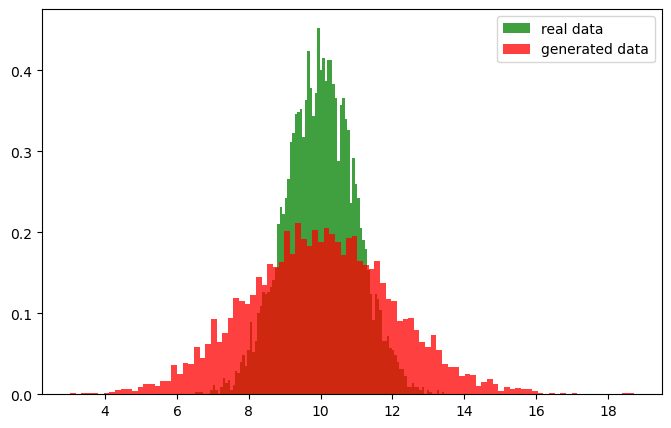

In [11]:
plot_distribution(X,Xhat,discriminator=None,density=True)

In the case above, since we just add 10 to the latent variable $z$, we transform $z$ using a deterministic function. We can call this an implicit generative model.


## The Generator


There are two networks involved in a GAN, the Generator and the Discriminator. Let's understand the Generator network first.

The Generator is a neural network denoted by $G$; the idea is that a neural network can approximate any function (by the [Universal Approximation Theorem](https://en.wikipedia.org/wiki/Universal_approximation_theorem?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML311Coursera35714171-2022-01-01)), so you should be able to generate data samples from any type of distribution.

Our goal is to convert the samples, $\mathbf{z}$, to one that approximates $\hat{\mathbf{x}}$,  i.e $\hat{\mathbf{x}}=G(\mathbf{z})$. Let's build a simple Generator $G(\mathbf{z})=\mathbf{W}^{T}\mathbf{z}+\mathbf{b} $ using Keras.

The following is a function that outputs a generator using Kera's Sequential model object.

GAN 涉及两个网络：生成器（Generator）和判别器（Discriminator）。我们先来了解生成器网络。

生成器是一个神经网络，记作 $G$；根据[通用近似定理](https://en.wikipedia.org/wiki/Universal_approximation_theorem?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML311Coursera35714171-2022-01-01)，神经网络可以逼近任意函数，因此我们可以用它来从任意分布中生成数据样本。

我们的目标是将噪声样本 $\mathbf{z}$ 转换成逼近真实数据的样本 $\hat{\mathbf{x}}$，即

$$
\hat{\mathbf{x}} = G(\mathbf{z}).
$$

下面我们用 Keras 构建一个简单的生成器模型，形如

$$
G(\mathbf{z}) = \mathbf{W}^T \mathbf{z} + \mathbf{b}.
$$

以下函数使用 Keras 的 `Sequential` 模型对象来输出这样一个生成器：



In [12]:
def make_generator_model():
    generator = tf.keras.Sequential()
    generator.add(layers.Dense(1))
    return generator

We can use the Generator to convert $\mathbf{z}$ and make a prediction $\hat{\mathbf{x}}$, and display the histogram of the distributions of $\hat{\mathbf{x}}$ and $\mathbf{x}$. As the model is not trained, the trained distributions are quite different:


Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor


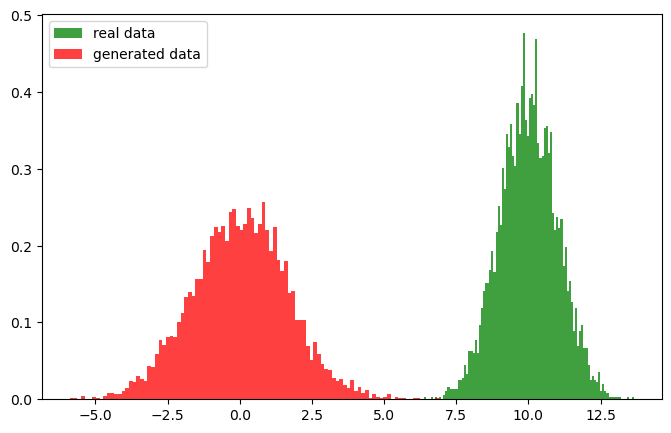

In [13]:
generator=make_generator_model()

Xhat = generator(Z, training=False)
plot_distribution(real_data=X,generated_data=Xhat)

We will discuss the use of the parameter `training=False` later on.


## The Discriminator


The discriminator $D(\mathbf{x})$ is a neural network that learns to distinguish between actual and generated samples. The simplest Discriminator is a simple logistic regression function. Let's create a discriminator in Keras with one Dense layer; we leave the logistic function out as it will be incorporated in the cost function, which is the convention in Keras.

判别器 $D(\mathbf{x})$ 是一个神经网络，用于学习区分**真实样本**和**生成样本**。最简单的判别器可以看作一个逻辑回归（logistic regression）模型。

下面我们用 Keras 创建一个判别器，只包含一个全连接层（`Dense`）。我们不在这一层添加 Sigmoid 激活，因为在 Keras 中通常将它与损失函数（`binary_crossentropy`）配合使用，后者内部会自动应用 Sigmoid。


In [14]:
def make_discriminator_model():
    discriminator=tf.keras.Sequential()
    discriminator.add(layers.Dense(1))
    return discriminator

discriminator=make_discriminator_model()

The discriminator and generator are randomly initialized, but we can plot the output of each and compare it to the true data distribution, with the generated data in red and the real data in green, and the logistic function as a function of the x axis. We also include the threshold. If the output of the logistic function is less than 0.5, the sample is classified as generated data; conversely, if the output is greater than 0.5, the sample will be classified as data that came from the real distribution.

生成器和判别器的参数都是随机初始化的，但我们可以将它们的输出绘制出来，与真实数据的分布进行对比：

* **生成数据** 用红色表示，
* **真实数据** 用绿色表示，
* 横轴是输入值 $x$，纵轴是逻辑函数的输出值。

图中还会画出决策阈值线：当逻辑函数的输出小于 0.5 时，该样本被判为“生成数据”；反之，当输出大于 0.5 时，则判为“真实数据”。



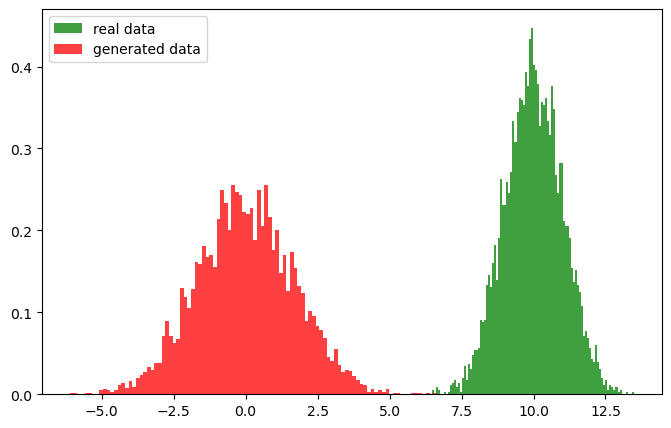

In [15]:
plot_distribution(real_data=X,generated_data=Xhat,discriminator=discriminator)

Applying the sigmoid function to the discriminator output, we get the probabilites that the samples belong to the real distribution. We can count the number of true samples that the discriminator correctly classifies.

For the real data, the discriminator successfully assigns a probability greater than 0.5 for all 5000 samples:

应用 Sigmoid 函数到判别器的输出后，我们就得到了样本属于真实分布的概率。我们可以统计判别器将真实样本正确分类的数量。

对于真实数据，判别器成功地为所有 5000 个样本分配了大于 0.5 的概率：


In [16]:


from tensorflow.keras import backend as K

logits = discriminator(X, training=False)
probs  = tf.math.sigmoid(logits)

# 先用 K.eval 取值
probs_np = K.eval(logits)

print(np.sum(probs_np>0.5))

0


For the generated data, only 1425 out of the 5000 samples are classified as having more than 50% chance of coming from the real distribution.


In [17]:
py_x=discriminator(Xhat)
np.sum(K.eval(py_x)>0.5)

1537

We can also use the follwoing to find the average value of the sigmoid function for all the samples.


In [20]:
import tensorflow as tf
from tensorflow.keras import backend as K

def get_accuracy(X_real, X_fake):
    # 1. 判别器对真实和生成数据的 logits
    logits_real = discriminator(X_real, training=False)
    logits_fake = discriminator(X_fake, training=False)

    # 2. 转为概率
    probs_real = tf.math.sigmoid(logits_real)
    probs_fake = tf.math.sigmoid(logits_fake)

    # 3. 计算分别的准确率
    acc_real = tf.reduce_mean(tf.cast(probs_real > 0.5, tf.float32))  # 真实样本被判为真
    acc_fake = tf.reduce_mean(tf.cast(probs_fake < 0.5, tf.float32))  # 生成样本被判为假

    # 4. 总体准确率
    accuracy = (acc_real + acc_fake) / 2.0

    # 5. 用 K.eval() 取值并返回
    return K.eval(accuracy)

# 现在再调用：
acc = get_accuracy(X, Xhat)
print("Accuracy:", acc)



Accuracy: 0.2519


In many cases, we can instead study the difference in the distribution; in this case, the discriminator is called a <a href='https://arxiv.org/pdf/2107.06700.pdf?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML311Coursera35714171-2022-01-01'>Critic</a>, a real-valued function.


## The Loss Fuction  GANs (optional)

GANs convert an unsupervised learning problem to a supervised one. Instead of formulating the problem like a two-player minimax game with a value function like in <a href=https://arxiv.org/pdf/1406.2661.pdf?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML311Coursera35714171-2022-01-01 >\[1]</a>, we can treat the problem of maximizing the familiar log-likelihood of the logistic function analogous to minimizing the cross-entropy loss, then incorporate the generator and discriminator.

### Discriminator

In order to train the GANS, we start off with standard maximization of the likelihood for the discriminator for the standard dataset $\mathcal{D}={{(x\_1, y\_1), ..., (x_N, y_N)}}$:

$$V(D)=\sum\_{n=1}^N \left( y_n \ln(D(\mathbf{x}\_n))+(1-y_n) \ln(1-D(\mathbf{x}\_n))\right)$$

Where $y=1$ for samples from the true distribution and $y=0$ for samples from the generator. The goal is to maximize this term with respect to $D$:

$$max\_{D}(V(D))$$

## GAN 的损失函数（可选）

GAN 将一个无监督学习问题转换成一个监督学习问题。我们不必像原论文$1$中那样用一个两人零和博弈的价值函数来表述，而是可以将问题看作**最大化逻辑函数的对数似然**（即**最小化交叉熵损失**）并将生成器和判别器一起纳入该框架中。

### 判别器

为了训练 GAN，我们首先对判别器 $D$ 在数据集 $\mathcal{D} = \{(x_1,y_1), \dots, (x_N,y_N)\}$ 上的**对数似然**进行最大化：

$$
V(D) \;=\; \sum_{n=1}^N \Bigl[y_n \ln D(\mathbf{x}_n)\;+\;(1-y_n)\ln\bigl(1 - D(\mathbf{x}_n)\bigr)\Bigr],
$$

其中，对于**真实样本** $x_n$，标签 $y_n = 1$；对于**生成样本** $x_n$，标签 $y_n = 0$。
判别器的目标是**最大化**这个对数似然：

$$
\max_{D} \; V(D).
$$

---

$1$ Ian J. Goodfellow et al., “Generative Adversarial Networks,” 2014.



To also incorporate the generated samples, we augment the right side of the equation with the generated $k$th sample $\hat{\mathbf{x}}\_k$. As they are not part of the dataset $k \notin \mathcal{D} $, we have to include a second summation where $y=0$. Finally, combining the cases of $y=1$ and $y=0$, we get:

$$V(D)=\sum\_{ n	\in \mathcal{D}}  \ln(D(\mathbf{x}*n))+\sum*{k 	\notin \mathcal{D}} \ln(1-D(\hat{\mathbf{x}}\_k) ) $$

我们还需要将生成器产生的样本也纳入判别器的训练，因此在原始数据集 $\mathcal{D}$ 上的求和之外，再对生成样本 $\hat{\mathbf{x}}_k$（此时 $k \notin \mathcal{D}$）做一次求和，并将其标签视为 $y=0$。合并两种情况（真实样本 $y=1$ 和生成样本 $y=0$）后，判别器的目标函数就写成：

$$
V(D)
\;=\;
\sum_{n \in \mathcal{D}} \ln\bigl(D(\mathbf{x}_n)\bigr)
\;+\;
\sum_{k \notin \mathcal{D}} \ln\!\bigl(1 - D(\hat{\mathbf{x}}_k)\bigr).
$$


### Generator

For the generator we simply replace $\hat{\mathbf{x}}\_k$ with the $G(\mathbf{z}\_k)$ .

$$V(G,D)=\sum\_{n	\in \mathcal{D}} \ln(D(\mathbf{x}*n))+\sum*{k 	\notin \mathcal{D}} \ln(1-D(G(\mathbf{z}\_k))) $$

As this is a density estimation problem, it is common to replace the summation with the expected value like in <a href=https://arxiv.org/pdf/1406.2661.pdf?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML311Coursera35714171-2022-01-01 >\[1]</a>. We replace the summations with an expectation where $p(\mathbf{x})$ is the true distribution and $p(\mathbf{z})$ is the distribution of $\mathbf{z}$.

$$V(D,G)=\mathbb{E}*{x\sim p(\mathbf{x})} \ln(D(\mathbf{x})) + \mathbb{E}*{\mathbf{z} \sim p(\mathbf{z})} \ln(1-D(G(\mathbf{z}) )) $$

As we are trying to trick the discriminator, we would like to find a $G$ that minimize the above expression, such as:

$$min\_{G} max\_{D} V(D,G)$$

### 生成器

对于生成器，我们只需将生成样本 $\hat{\mathbf{x}}_k$ 替换为 $G(\mathbf{z}_k)$：

$$
V(D, G)
=
\sum_{n \in \mathcal{D}} \ln\bigl(D(\mathbf{x}_n)\bigr)
\;+\;
\sum_{k \notin \mathcal{D}} \ln\!\bigl(1 - D\bigl(G(\mathbf{z}_k)\bigr)\bigr).
$$

由于这本质上是一个**密度估计**问题，通常会像原论文$1$那样，将求和替换为期望值的形式。设 $p(\mathbf{x})$ 为真实数据的分布，$p(\mathbf{z})$ 为噪声（潜在变量）的分布，则可写为：

$$
V(D, G)
=
\mathbb{E}_{\mathbf{x}\sim p(\mathbf{x})}\bigl[\ln D(\mathbf{x})\bigr]
\;+\;
\mathbb{E}_{\mathbf{z}\sim p(\mathbf{z})}\bigl[\ln\bigl(1 - D\bigl(G(\mathbf{z})\bigr)\bigr)\bigr].
$$

因为我们的目的是“欺骗”判别器，所以我们要寻找一个 $G$，使得在最优判别器 $D$ 面前，这个值函数被**最小化**：

$$
\min_{G}\;\max_{D}\;V(D, G).
$$

---

$1$ Ian J. Goodfellow 等人, “Generative Adversarial Networks,” 2014.



## Training GANS

### Training Generator

GANs are quite difficult to train, even for a simple example. Let's start off with training the generator in practice.

$log(1 − D(G(\mathbf{z})))$ is difficult to work with as $D(G(\mathbf{z}))$ is near one or zero for the first few iterations. This is because the generator is not yet properly trained, and the discriminator can easily distinguish between the generated and actual samples. Therefore we maximize $log(D(G(\mathbf{z}\_k)) )$.

Although the output of the generator passes through the discriminator, we do not update the generator in the optimization step, hence we set the parameter `training=False` in the actual training steps.

Instead of maximizing the term, we can take the negative and minimize it. The resultant expression can be calculated in Keras using the cross-entropy loss where all the target values are set to one:

$$\sum\_{k 	\notin \mathcal{D}} log(1 - D(G(\mathbf{z}\_k)) )$$

## 训练 GAN

### 训练生成器

GAN 的训练非常棘手，即便是简单示例也不例外。下面我们来看实际中如何开始训练生成器。

对于公式中的项 $\log(1 - D(G(\mathbf{z})))$，在最初几次迭代中往往难以使用，因为此时生成器尚未训练好，判别器可以轻松地区分生成样本和真实样本，导致 $D(G(\mathbf{z}))$ 非常接近 0 或 1，从而使梯度消失。因此，在训练生成器时，我们**最大化** $\log\bigl(D(G(\mathbf{z}_k))\bigr)$，而不是原始论文中的那一项。

尽管生成器的输出要经过判别器，**但在优化生成器参数时，我们并不更新判别器的权重**，所以在调用判别器时要指定 `training=False`。

在实际实现中，我们通常将最大化问题转换为最小化问题：对目标取负号，并使用交叉熵损失函数，其中“标签”统一设为 1。这对应于在 Keras 中调用：

```python
# 生成器训练时的损失
# 假设 logits_fake = D(G(z))
loss_g = tf.keras.losses.binary_crossentropy(
    y_true=tf.ones_like(logits_fake),  # 目标全为 1
    y_pred=tf.sigmoid(logits_fake)     # 判别器对生成样本的概率
)
```

数学表达式是：

$$
\min_{G}\; -\sum_{k \notin \mathcal{D}} \log\bigl(D(G(\mathbf{z}_k))\bigr),
$$

等价于最大化 $\sum \log\bigl(D(G(\mathbf{z}_k))\bigr)$。



In [21]:
# This method returns a helper function to compute crossentropy loss
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)
def generator_loss(Xhat):
    return cross_entropy(tf.ones_like(Xhat), Xhat)

### Training Discriminator

We can also use the cross-entropy to train the discriminator; we simply multiply $V(G,D)$ by a negative number, set $y=0$ for the generated values and $y=1$ for the real values. We do not update the generator parameters.

$$V(G)=\sum\_{n	\in \mathcal{D}} (\ln(D(\mathbf{x}*n)))+\sum*{k 	\notin \mathcal{D}} \ln(1-D(G(\mathbf{z}\_k) )) $$

### 训练判别器

我们同样可以使用交叉熵来训练判别器；将目标函数 $V(G, D)$ 取负号，然后对**生成样本**设定 $y=0$，对**真实样本**设定 $y=1$。在这一阶段，我们**不更新生成器**的参数。

数学表达式为：

$$
V(D) 
= 
\sum_{n \in \mathcal{D}} \ln\bigl(D(\mathbf{x}_n)\bigr)
\;+\;
\sum_{k \notin \mathcal{D}} \ln\!\bigl(1 - D\bigl(G(\mathbf{z}_k)\bigr)\bigr).
$$

对应到交叉熵损失的实现可以写作：

```python
# 判别器训练时的损失
# 假设 logits_real = D(x_real), logits_fake = D(G(z))
loss_real = tf.keras.losses.binary_crossentropy(
    y_true=tf.ones_like(logits_real),   # 真实样本标签为 1
    y_pred=tf.sigmoid(logits_real)
)
loss_fake = tf.keras.losses.binary_crossentropy(
    y_true=tf.zeros_like(logits_fake),  # 生成样本标签为 0
    y_pred=tf.sigmoid(logits_fake)
)
loss_d = loss_real + loss_fake
```

这样，判别器就会学习在固定生成器参数的条件下，**最大化**对真实样本打 1、对生成样本打 0 的对数似然（等价于最小化上述交叉熵）。



The first term is the real loss and the second is the fake loss in Keras.


In [22]:
def discriminator_loss(X, Xhat):
    real_loss = cross_entropy(tf.ones_like(X), X)
    fake_loss = cross_entropy(tf.zeros_like(Xhat), Xhat)
    total_loss = 0.5*(real_loss + fake_loss)
    return total_loss

We create the optimizer for the discriminator and generator:


In [23]:
generator_optimizer = tf.keras.optimizers.Adam(5e-1,beta_1=0.5,beta_2=0.8)

discriminator_optimizer = tf.keras.optimizers.Adam(5e-1,beta_1=0.5, beta_2=0.8)


We now train the model; as the dataset is small, we will use batch gradient descent.

For each iteration we will generate $M$ real examples ${\mathbf{x}*{1}, ...,\mathbf{x}*{M}}$, these are from the generating distribution $p(\mathbf{x})$. This would be our actual dataset if we used real data.

We will then generate a sample batch of $M$ noise samples ${\mathbf{z}*{1}, ...,\mathbf{z}*{M}}$ from noise prior $p(\mathbf{z})$ and convert the result to a generated image using the generator ${\hat{\mathbf{x}}*{1}, ...,\hat{\mathbf{x}}*{M}}$.

We determine the output of the discriminator for both the real and generated samples. We calculate the loss and then update the discriminator and generator through their respective stochastic gradients.


The convergence of GAN training is a subject in itself. But let's explore a method that works for this simple dataset. Intuitively, we know that if our generated data is identical to our actual data, the probability of correctly classifying is random. Therefore if the generated and actual data are of equal proportion, $D(\mathbf{x}\_n)=0.5$ and $D(\hat{\mathbf{x}}\_n)=0.5$.

We only display iterations where the average discriminator output gets closer to 50% for both the generated data and actual data.


In [24]:
#paramters for trainng 
epochs=20
BATCH_SIZE=5000
noise_dim=1
epsilon=100 


#discrimator and gernerator 
tf.random.set_seed(0)
discriminator=make_discriminator_model()
generator=make_generator_model()

tf.config.run_functions_eagerly(True)



gen_loss_epoch=[]
disc_loss_epoch=[]
plot_distribution(real_data=X,generated_data=Xhat,discriminator=discriminator )
print("epoch",0)

for epoch in tqdm(range(epochs)):
    #data for the true distribution of your real data samples training ste
    x = tf.random.normal((BATCH_SIZE,1),mean=10,stddev=1.0)
    #random samples it was found if you increase the  stander deviation, you get better results 
    z= tf.random.normal([BATCH_SIZE, noise_dim],mean=0,stddev=10)
    # needed to compute the gradients for a list of variables.
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        #generated sample 
        xhat = generator(z, training=True)
        #the output of the discriminator for real data 
        real_output = discriminator(x, training=True)
        #the output of the discriminator  data
        fake_output = discriminator(xhat, training=True)
        #loss for each 
        gen_loss= generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)
    # Compute the gradients for gen_loss and generator
    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    # Compute the gradients for gen_loss and discriminator
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)
    # Ask the optimizer to apply the processed gradients
    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))
  
  # Save and display the generator and discriminator if the performance increases 
    if abs(0.5-get_accuracy(x,xhat))<epsilon:
        epsilon=abs(0.5-get_accuracy(x,xhat))
        generator.save('generator')
        discriminator.save('discriminator')
        print(get_accuracy(x,xhat))
        plot_distribution(real_data=X,generated_data=xhat,discriminator=discriminator )
        print("epoch",epoch)

AttributeError: module 'tensorflow._api.v1.random' has no attribute 'set_seed'

For more on training GANs check out the following <a href="https://jonathan-hui.medium.com/gan-why-it-is-so-hard-to-train-generative-advisory-networks-819a86b3750b?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML311Coursera35714171-2022-01-01">blog</a>. We can display the best performing model


In [25]:
generator=make_generator_model()
generator= models.load_model('generator')
xhat=generator(z)
discriminator=models.load_model('discriminator')
plot_distribution(real_data=X,generated_data=xhat,discriminator=discriminator )

OSError: Unable to open file (unable to open file: name = 'generator', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

We usually use this version of TensorFlow for the rest of the course, so don't forget to downgrade


In [26]:
%%capture
!pip install --upgrade tensorflow==1.14.0

**Thank you for completing this lab!**

## Author

<a href="https://www.linkedin.com/in/joseph-s-50398b136/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML0101ENSkillsNetwork20718538-2021-01-01" target="_blank">Joseph Santarcangelo</a>

## Change Log

Change Log

| Date (YYYY-MM-DD) | Version | Changed By         | Change Description |
| ----------------- | ------- | ------------------ | ------------------ |
| 2022-06-31        | 0.1     | Joseph Santarcange | Created lab        |
| 2022-09-09        | 0.1     | Steve Hord         | QA pass edits      |

## <h3 align="center"> © IBM Corporation 2022. All rights reserved. <h3/>
